# Desafío - Identificación de escenarios naturales del mundo

### 1. Importa correctamente los conjuntos de datos, desplegando la cantidad de registros de cada categoría para cada conjunto. Despliega ocho imágenes aleatorias del conjunto de entrenamiento y codifica las etiquetas con OneHotEncoder para los conjuntos de entrenamiento y Test.


In [1]:
# Importamos librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Importamos OneHotEncoder para codificar las etiquetas
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Importamos Tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping



# Cargamos los conjuntos de datos entregados para el desafío
cnn_train_X = np.load('cnn_train_X.npy', allow_pickle=True)
cnn_train_y = np.load('cnn_train_y.npy', allow_pickle=True)

cnn_test_X = np.load('cnn_test_X.npy', allow_pickle=True)
cnn_test_y = np.load('cnn_test_y.npy', allow_pickle=True)

cnn_pred_X = np.load('cnn_pred_X.npy', allow_pickle=True)

# Mostramos las dimensiones de cada conjunto
print("X_train:", cnn_train_X.shape)
print("y_train:", cnn_train_y.shape)
print("X_test :", cnn_test_X.shape)
print("y_test :", cnn_test_y.shape)
print("X_pred :", cnn_pred_X.shape)

# Revisamos el rango de valores de los pixeles
print("Valor mínimo train:", cnn_train_X.min())
print("Valor máximo train:", cnn_train_X.max())

X_train: (14034, 32, 32, 3)
y_train: (14034,)
X_test : (3000, 32, 32, 3)
y_test : (3000,)
X_pred : (7301, 32, 32, 3)
Valor mínimo train: 0.0
Valor máximo train: 1.0


Se cargaron correctamente los conjuntos de entrenamiento, prueba y predicción. Las imágenes tienen dimensiones de 32x32 píxeles con 3 canales de color, lo que indica que corresponden a imágenes RGB. Además, se verificó que los valores de los píxeles se encuentran normalizados entre 0 y 1, por lo que no fue necesario aplicar una normalización adicional antes de entrenar los modelos.

In [2]:
# Calculamos la frecuencia de cada clase en el conjunto de entrenamiento.
# Esto permite verificar que todas las categorías estén representadas
# y detectar posibles desbalances entre ellas.
train_counts = pd.Series(cnn_train_y).value_counts().sort_index()

print("Cantidad de registros por categoría - Train:")
print(train_counts)

Cantidad de registros por categoría - Train:
buildings    2191
forest       2271
glacier      2404
mountain     2512
sea          2274
street       2382
Name: count, dtype: int64


El conjunto de entrenamiento presenta una distribución equilibrada entre las seis categorías. Aunque existen pequeñas diferencias en la cantidad de imágenes por clase, no se observa un desbalance significativo que pueda afectar el entrenamiento del modelo o favorecer una categoría sobre las demás.

In [3]:
# Calculamos la frecuencia de cada clase en el conjunto de prueba.
test_counts = pd.Series(cnn_test_y).value_counts().sort_index()

print("Cantidad de registros por categoría - Test:")
print(test_counts)

Cantidad de registros por categoría - Test:
buildings    437
forest       474
glacier      553
mountain     525
sea          510
street       501
Name: count, dtype: int64


El conjunto de prueba también presenta una distribución equilibrada entre las seis categorías. Esto permite evaluar el rendimiento del modelo de forma representativa, ya que ninguna clase concentra una cantidad excesiva o insuficiente de imágenes que pueda sesgar las métricas obtenidas.

In [4]:
# Construimos una tabla comparativa con la cantidad de imágenes
# de cada categoría en los conjuntos de entrenamiento y prueba.
# Esto facilita verificar que ambas particiones mantienen una
# distribución similar de las clases.
frecuencias = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

display(frecuencias)

,Train,Test
buildings,2191,437
forest,2271,474
glacier,2404,553
mountain,2512,525
sea,2274,510
street,2382,501


La comparación entre los conjuntos de entrenamiento y prueba muestra que ambos mantienen una distribución similar de las seis categorías. Esto asegura que el conjunto de prueba sea representativo del conjunto de entrenamiento, permitiendo evaluar el rendimiento y la capacidad de generalización del modelo de manera confiable.

In [5]:
# Obtenemos las clases únicas presentes en el conjunto de entrenamiento.
# Estas corresponden a las categorías que la red neuronal deberá aprender
# a distinguir durante el proceso de clasificación.
clases = np.unique(cnn_train_y)

print("Clases:", clases)

Clases: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


Se identificaron correctamente las seis categorías presentes en el conjunto de entrenamiento: **buildings, forest, glacier, mountain, sea** y **street**. Estas clases corresponden a las etiquetas que la red neuronal deberá aprender a distinguir durante el proceso de entrenamiento y serán utilizadas posteriormente para interpretar las predicciones realizadas por los modelos.

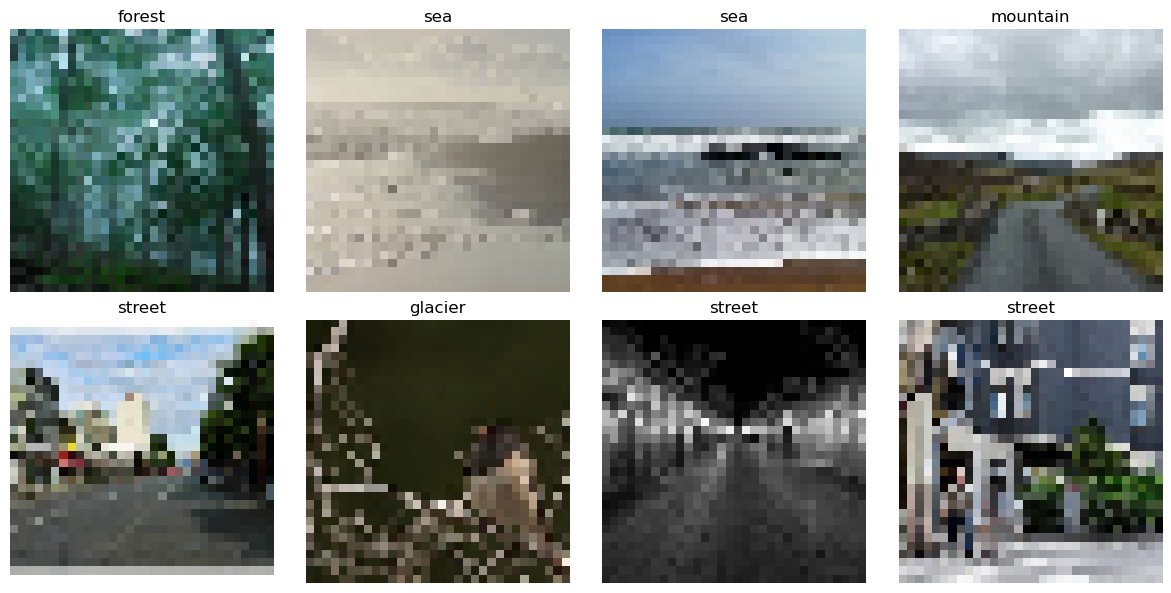

In [6]:
# Seleccionamos de forma aleatoria ocho imágenes del conjunto de
# entrenamiento para realizar una inspección visual del dataset.
# Se fija una semilla para obtener siempre la misma selección
# y facilitar la reproducibilidad de los resultados.
np.random.seed(42)

indices = np.random.choice(
    len(cnn_train_X),
    size=8,
    replace=False
)

# Mostramos las imágenes seleccionadas junto con su etiqueta
# correspondiente para verificar visualmente las distintas clases.
plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    plt.subplot(2, 4, i + 1)
    plt.imshow(cnn_train_X[idx])
    plt.title(cnn_train_y[idx])
    plt.axis('off')

plt.tight_layout()
plt.show()

La inspección visual de una muestra aleatoria del conjunto de entrenamiento permitió verificar que las imágenes corresponden a las seis categorías del problema y presentan una adecuada diversidad de escenarios. Además, se observó que las imágenes ya se encuentran redimensionadas a **32×32 píxeles**, lo que constituye el formato de entrada requerido para el entrenamiento de las redes neuronales.

In [7]:
# Creamos un codificador OneHotEncoder para transformar las etiquetas
# categóricas en vectores binarios, formato requerido por las redes
# neuronales para problemas de clasificación multiclase.
encoder = OneHotEncoder(
    sparse_output=False
)

# Ajustamos el codificador utilizando las etiquetas del conjunto de
# entrenamiento y posteriormente transformamos tanto el conjunto de
# entrenamiento como el de prueba.
cnn_train_y_encoded = encoder.fit_transform(
    cnn_train_y.reshape(-1, 1)
)

cnn_test_y_encoded = encoder.transform(
    cnn_test_y.reshape(-1, 1)
)

# Verificamos las dimensiones de las etiquetas antes y después
# de aplicar la codificación One-Hot.
print("y_train original:", cnn_train_y.shape)
print("y_train encoded :", cnn_train_y_encoded.shape)

print("y_test original :", cnn_test_y.shape)
print("y_test encoded  :", cnn_test_y_encoded.shape)
# Mostramos las categorías identificadas por el codificador.
print("Clases codificadas:", encoder.categories_)

y_train original: (14034,)
y_train encoded : (14034, 6)
y_test original : (3000,)
y_test encoded  : (3000, 6)
Clases codificadas: [array(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'],
      dtype=object)]


Se importaron correctamente los conjuntos de entrenamiento, prueba y predicción. Las imágenes poseen dimensiones de 32x32 píxeles con tres canales de color (RGB) y se encuentran normalizadas en el rango [0,1]. Se verificó que las seis categorías (buildings, forest, glacier, mountain, sea y street) presentan una distribución relativamente equilibrada tanto en entrenamiento como en prueba, lo que favorece el aprendizaje de los modelos. Además, se visualizaron ocho imágenes aleatorias para inspeccionar visualmente el contenido del dataset y posteriormente las etiquetas fueron codificadas mediante OneHotEncoder, obteniendo matrices de dimensión (14034, 6) para entrenamiento y (3000, 6) para prueba.

### 2. Implementa una red neuronal multicapa Fully Connected para clasificar las imágenes, las que deben contener un mínimo de cinco capas ocultas. Despliega las métricas (aplicadas al conjunto de test) que estimes conveniente para medir el rendimiento del modelo.


In [8]:
# Transformamos las imágenes en vectores unidimensionales para poder
# utilizarlas como entrada de una red neuronal Fully Connected.
# Cada imagen de 32x32 píxeles con 3 canales RGB se convierte en un
# vector de 3072 características (32 × 32 × 3).
X_train_flat = cnn_train_X.reshape(
    cnn_train_X.shape[0],
    32 * 32 * 3
)

X_test_flat = cnn_test_X.reshape(
    cnn_test_X.shape[0],
    32 * 32 * 3
)
# Verificamos las dimensiones de los conjuntos de entrenamiento
# y prueba después del proceso de aplanamiento.
print("X_train_flat:", X_train_flat.shape)
print("X_test_flat :", X_test_flat.shape)

X_train_flat: (14034, 3072)
X_test_flat : (3000, 3072)


Las imágenes fueron transformadas correctamente desde una matriz de **32×32×3** a un vector de **3072 características**, permitiendo utilizarlas como entrada de la red neuronal Fully Connected. Se verificó que tanto el conjunto de entrenamiento como el de prueba conservan la cantidad de observaciones, modificándose únicamente la forma de representación de cada imagen.

In [9]:
# Construimos una red neuronal Fully Connected compuesta por cinco
# capas ocultas, cumpliendo con el requisito solicitado en el desafío.
# La arquitectura utiliza funciones de activación ReLU en las capas
# ocultas y una función Softmax en la capa de salida para realizar
# la clasificación de las seis categorías de imágenes.
fc_model = Sequential()

# Capa de entrada y primera capa oculta
fc_model.add(Dense(
    512,
    activation='relu',
    input_shape=(X_train_flat.shape[1],)
))

# Segunda capa oculta
fc_model.add(Dense(
    256,
    activation='relu'
))

# Tercera capa oculta
fc_model.add(Dense(
    128,
    activation='relu'
))

# Cuarta capa oculta
fc_model.add(Dense(
    64,
    activation='relu'
))

# Quinta capa oculta
fc_model.add(Dense(
    32,
    activation='relu'
))

# Capa de salida con seis neuronas, una por cada categoría.
# La función Softmax entrega la probabilidad de pertenencia
# a cada una de las clases.
fc_model.add(Dense(
    6,
    activation='softmax'
))

# Compilamos el modelo utilizando el optimizador Adam y la
# función de pérdida Categorical Crossentropy, apropiada para
# problemas de clasificación multiclase.
fc_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostramos un resumen de la arquitectura del modelo,
# incluyendo el número de capas y parámetros entrenables.
fc_model.summary()

c:\Users\deadm\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,748,134 (6.67 MB)

 Trainable params: 1,748,134 (6.67 MB)

 Non-trainable params: 0 (0.00 B)

Se construyó correctamente una red neuronal **Fully Connected** compuesta por cinco capas ocultas y una capa de salida con seis neuronas, una para cada categoría del problema. La arquitectura cuenta con **1.748.134 parámetros entrenables**, proporcionando una capacidad suficiente para aprender patrones presentes en las imágenes antes de evaluar su desempeño sobre el conjunto de prueba.

In [10]:
# Entrenamos la red neuronal Fully Connected utilizando el conjunto
# de entrenamiento. Durante cada época también se evalúa el modelo
# sobre el conjunto de prueba para monitorear su capacidad de
# generalización y detectar posibles signos de sobreajuste.
history_fc = fc_model.fit(
    X_train_flat,
    cnn_train_y_encoded,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_flat, cnn_test_y_encoded),
    verbose=1
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.4353 - loss: 1.4278 - val_accuracy: 0.5137 - val_loss: 1.2803
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5301 - loss: 1.2197 - val_accuracy: 0.5203 - val_loss: 1.2476
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5614 - loss: 1.1355 - val_accuracy: 0.5747 - val_loss: 1.1404
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5832 - loss: 1.0912 - val_accuracy: 0.5430 - val_loss: 1.2024
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5983 - loss: 1.0577 - val_accuracy: 0.5560 - val_loss: 1.1674
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5985 - loss: 1.0488 - val_accuracy: 0.5847 - val_loss: 1.1225
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6175 - loss: 1.0082 - val_accuracy: 0.5903 - val_loss: 1.0762
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6250 - loss: 0.9878 - val_accu

El modelo Fully Connected completó correctamente el proceso de entrenamiento durante las 20 épocas establecidas. A lo largo del entrenamiento se observó una disminución progresiva de la función de pérdida y un aumento del Accuracy tanto en el conjunto de entrenamiento como en el conjunto de prueba utilizado para validación, lo que indica que la red fue capaz de aprender patrones relevantes presentes en las imágenes antes de realizar la evaluación final.

In [11]:
# Evaluamos el rendimiento del modelo utilizando el conjunto de prueba.
# Se calcula la función de pérdida (Loss) y el Accuracy sobre datos
# que no fueron utilizados durante el entrenamiento, permitiendo medir
# la capacidad de generalización del modelo.
loss_fc, accuracy_fc = fc_model.evaluate(
    X_test_flat,
    cnn_test_y_encoded,
    verbose=0
)
# Mostramos las métricas obtenidas en el conjunto de prueba.
print("Loss Test:", round(loss_fc, 4))
print("Accuracy Test:", round(accuracy_fc, 4))

Loss Test: 1.0969
Accuracy Test: 0.6077


Al evaluar el modelo sobre el conjunto de prueba, se obtuvo un **Accuracy de 60,77%** y una **Loss de 1,0969**. Estos resultados muestran que la red neuronal Fully Connected fue capaz de clasificar correctamente una parte importante de las imágenes; sin embargo, aún presenta margen de mejora en su capacidad de generalización. Esto justifica la implementación de una arquitectura convolucional (CNN), la cual aprovecha mejor la información espacial de las imágenes y suele ofrecer un mejor desempeño en tareas de clasificación visual.

In [12]:
# Generamos las probabilidades de pertenencia a cada una de las
# seis clases utilizando el conjunto de prueba.
y_proba_fc = fc_model.predict(X_test_flat)

# Convertimos las probabilidades en la clase predicha, seleccionando
# aquella con la mayor probabilidad para cada imagen.
y_pred_fc = np.argmax(y_proba_fc, axis=1)

# Transformamos las etiquetas reales codificadas con One-Hot a su
# representación original para poder compararlas con las predicciones.
y_true_fc = np.argmax(cnn_test_y_encoded, axis=1)

# Obtenemos los nombres de las clases utilizados durante la codificación.
class_names = encoder.categories_[0]

# Mostramos el reporte de clasificación, el cual incluye las métricas
# Precision, Recall, F1-Score y Support para cada una de las categorías.
print("Classification Report - Fully Connected")
print(classification_report(
    y_true_fc,
    y_pred_fc,
    target_names=class_names
))

# Mostramos la matriz de confusión para analizar la cantidad de
# clasificaciones correctas e incorrectas realizadas por el modelo
# para cada una de las categorías.
print("Matriz de confusión:")
print(confusion_matrix(
    y_true_fc,
    y_pred_fc
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Classification Report - Fully Connected
              precision    recall  f1-score   support

   buildings       0.50      0.45      0.47       437
      forest       0.82      0.73      0.77       474
     glacier       0.63      0.63      0.63       553
    mountain       0.53      0.75      0.62       525
         sea       0.59      0.32      0.41       510
      street       0.62      0.75      0.68       501

    accuracy                           0.61      3000
   macro avg       0.61      0.60      0.60      3000
weighted avg       0.61      0.61      0.60      3000

Matriz de confusión:
[[197  24  32  70  22  92]
 [ 28 346   1  19  14  66]
 [ 21   2 346 117  40  27]
 [ 33   9  55 395  27   6]
 [ 64  21  98 124 163  40]
 [ 50  21  21  21  12 376]]


El **Classification Report** y la **matriz de confusión** muestran que el modelo Fully Connected obtuvo un rendimiento desigual entre las distintas categorías. Las clases **forest** y **street** alcanzaron los mejores resultados, mientras que **buildings** y, especialmente, **sea**, presentaron menores valores de *Recall* y *F1-Score*, evidenciando una mayor dificultad para ser clasificadas correctamente. En términos generales, el modelo alcanzó un **Accuracy cercano al 61%**, lo que confirma que, si bien logra aprender patrones relevantes, su capacidad para reconocer características espaciales de las imágenes es limitada, justificando el uso de una red neuronal convolucional (CNN) para mejorar el desempeño.

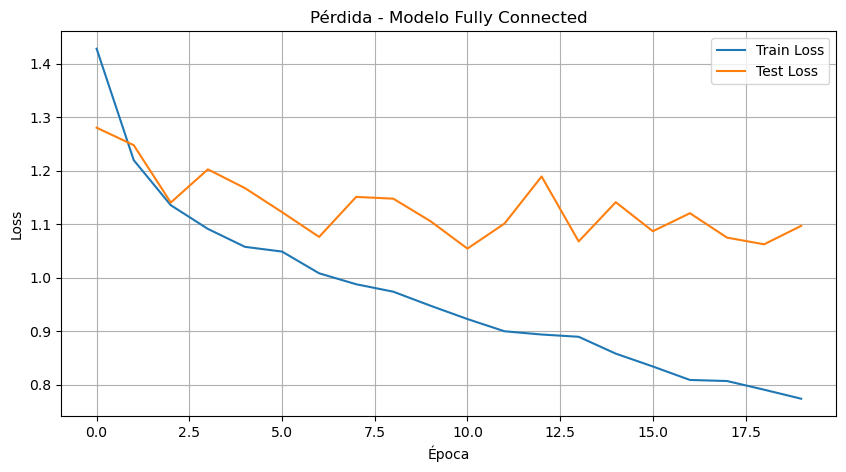

In [13]:
# Graficamos la evolución de la función de pérdida (Loss) durante
# el entrenamiento y la validación. Este gráfico permite analizar
# cómo disminuye el error del modelo en cada época y detectar
# posibles signos de sobreajuste si la pérdida de validación deja
# de disminuir o comienza a aumentar.
plt.figure(figsize=(10, 5))

plt.plot(history_fc.history['loss'], label='Train Loss')
plt.plot(history_fc.history['val_loss'], label='Test Loss')

plt.title('Pérdida - Modelo Fully Connected')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

La curva de pérdida muestra que el modelo logró reducir progresivamente el **Train Loss** a lo largo de las épocas, indicando que fue aprendiendo los patrones presentes en el conjunto de entrenamiento. Sin embargo, el **Test Loss** dejó de disminuir después de las primeras épocas y posteriormente presentó fluctuaciones, manteniéndose por encima de la pérdida de entrenamiento. Este comportamiento evidencia la aparición de **sobreajuste (overfitting)**, ya que el modelo continúa mejorando sobre los datos de entrenamiento, pero no logra el mismo nivel de desempeño sobre datos no vistos.

Se implementó una red neuronal Fully Connected con cinco capas ocultas para clasificar imágenes pertenecientes a seis categorías. Previamente, las imágenes fueron transformadas en vectores de 3072 características para ser utilizadas como entrada del modelo. Tras 20 épocas de entrenamiento, se obtuvo un Accuracy de 60,77% sobre el conjunto de prueba. Las clases con mejor desempeño fueron forest y street, mientras que buildings y sea presentaron mayores dificultades de clasificación. La matriz de confusión evidenció errores frecuentes entre categorías con características visuales similares, lo que sugiere que una arquitectura Fully Connected no logra aprovechar adecuadamente la información espacial presente en las imágenes. En consecuencia, se espera que las redes neuronales convolucionales implementadas en los siguientes apartados mejoren la capacidad de generalización y alcancen un rendimiento superior.

### 3. Desarrolla una red neuronal Convolucional usando tres o más capas convolucionales y dos o más capas densas, de manera que la cantidad de parámetros a estimar se encuentre en el intervalo [3MM, 8MM], con 25 épocas. Muestra la curva de la pérdida para cada época y la curva de la métrica accuracy (conjunto test).

In [14]:
# Construimos una red neuronal convolucional (CNN) para la clasificación
# de imágenes. La arquitectura está compuesta por cuatro capas
# convolucionales y dos capas densas, cumpliendo con los requisitos
# establecidos en el desafío. Además, el modelo posee aproximadamente
# 8 millones de parámetros entrenables, manteniéndose dentro del
# intervalo solicitado.
cnn_model = Sequential()

# Primer bloque convolucional.
# Se aplican 32 filtros de tamaño 3x3 para extraer características
# básicas de las imágenes, seguido de una operación MaxPooling que
# reduce las dimensiones espaciales y el costo computacional.
cnn_model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    padding='same',
    input_shape=(32, 32, 3)
))

cnn_model.add(MaxPooling2D(
    pool_size=(2, 2)
))

# Segundo bloque convolucional.
# Se incrementa el número de filtros para capturar patrones visuales
# de mayor complejidad.
cnn_model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation='relu',
    padding='same'
))

cnn_model.add(MaxPooling2D(
    pool_size=(2, 2)
))

# Tercer bloque convolucional.
# Continúa la extracción de características de alto nivel utilizando
# un mayor número de filtros.
cnn_model.add(Conv2D(
    filters=128,
    kernel_size=(3, 3),
    activation='relu',
    padding='same'
))

cnn_model.add(MaxPooling2D(
    pool_size=(2, 2)
))

# Cuarto bloque convolucional.
# Esta capa obtiene representaciones más abstractas de las imágenes
# antes de conectarlas con las capas densas.
cnn_model.add(Conv2D(
    filters=256,
    kernel_size=(3, 3),
    activation='relu',
    padding='same'
))

# Convertimos los mapas de características en un vector para alimentar
# las capas completamente conectadas.
cnn_model.add(Flatten())

# Primera capa densa.
# Contiene 1650 neuronas para realizar el aprendizaje de patrones
# complejos obtenidos por las capas convolucionales.
cnn_model.add(Dense(
    1650,
    activation='relu'
))
# Aplicamos Dropout para reducir el sobreajuste durante el entrenamiento.
cnn_model.add(Dropout(0.5))

# Segunda capa densa.
# Refina las representaciones aprendidas antes de la clasificación final.
cnn_model.add(Dense(
    512,
    activation='relu'
))

cnn_model.add(Dropout(0.3))

# Capa de salida.
# Contiene seis neuronas, una por cada categoría del problema.
# La función Softmax entrega la probabilidad de pertenencia a cada clase.
cnn_model.add(Dense(
    6,
    activation='softmax'
))

# Compilamos el modelo utilizando el optimizador Adam y la función
# de pérdida Categorical Crossentropy, apropiada para clasificación
# multiclase.
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostramos el resumen de la arquitectura para verificar el número
# de capas y la cantidad total de parámetros entrenables.
cnn_model.summary()

c:\Users\deadm\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1650)           │     6,760,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1650)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,996,856 (30.51 MB)

 Trainable params: 7,996,856 (30.51 MB)

 Non-trainable params: 0 (0.00 B)

Se implementó una red neuronal convolucional (CNN) compuesta por cuatro capas convolucionales, dos capas densas y una capa de salida para la clasificación de las seis categorías. La arquitectura incorpora capas de MaxPooling para reducir la dimensionalidad espacial y capas de Dropout para disminuir el riesgo de sobreajuste. Además, el modelo cuenta con 7.996.856 parámetros entrenables, cumpliendo el requisito de encontrarse dentro del intervalo de 3 a 8 millones de parámetros establecido en el desafío. Esta arquitectura está diseñada para aprovechar la información espacial de las imágenes, por lo que se espera un rendimiento superior al obtenido con la red Fully Connected.

In [15]:
# Entrenamos la red neuronal convolucional utilizando el conjunto
# de entrenamiento durante 25 épocas. En cada época el modelo es
# evaluado con el conjunto de prueba para monitorear su capacidad
# de generalización y analizar la evolución de las métricas de
# entrenamiento y validación.
history_cnn = cnn_model.fit(
    cnn_train_X,
    cnn_train_y_encoded,
    epochs=25,
    batch_size=64,
    validation_data=(cnn_test_X, cnn_test_y_encoded),
    verbose=1
)

Epoch 1/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.5470 - loss: 1.1292 - val_accuracy: 0.6223 - val_loss: 0.9647
Epoch 2/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.6994 - loss: 0.8054 - val_accuracy: 0.7237 - val_loss: 0.7551
Epoch 3/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 27s 121ms/step - accuracy: 0.7535 - loss: 0.6839 - val_accuracy: 0.7667 - val_loss: 0.6567
Epoch 4/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 27s 121ms/step - accuracy: 0.7842 - loss: 0.6038 - val_accuracy: 0.7840 - val_loss: 0.6151
Epoch 5/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - accuracy: 0.8070 - loss: 0.5433 - val_accuracy: 0.7793 - val_loss: 0.6142
Epoch 6/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - accuracy: 0.8371 - loss: 0.4571 - val_accuracy: 0.7520 - val_loss: 0.7324
Epoch 7/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.8545 - loss: 0.4028 - val_accuracy: 0.7907 - val_loss: 0.5923
Epoch 8/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.8731 - loss: 0

La red neuronal convolucional completó correctamente las 25 épocas de entrenamiento, mostrando una mejora progresiva en el aprendizaje. El Accuracy del conjunto de entrenamiento aumentó desde aproximadamente 54,7% hasta 98,1%, mientras que el Accuracy del conjunto de prueba alcanzó valores cercanos al 80% durante el entrenamiento. Asimismo, la función de pérdida disminuyó de forma importante en el conjunto de entrenamiento, aunque en las últimas épocas la pérdida y el Accuracy de validación comenzaron a estabilizarse e incluso mostraron un leve deterioro. Este comportamiento sugiere la aparición de sobreajuste, indicando que el modelo comienza a especializarse en los datos de entrenamiento sin obtener mejoras equivalentes sobre datos no vistos.

In [16]:
# Evaluamos el rendimiento de la red neuronal convolucional utilizando
# el conjunto de prueba. Se calcula la función de pérdida (Loss) y el
# Accuracy sobre imágenes que no fueron utilizadas durante el entrenamiento,
# permitiendo medir la capacidad de generalización del modelo.
loss_cnn, accuracy_cnn = cnn_model.evaluate(
    cnn_test_X,
    cnn_test_y_encoded,
    verbose=1
)
# Mostramos las métricas obtenidas en el conjunto de prueba.
print("Loss Test CNN:", round(loss_cnn, 4))
print("Accuracy Test CNN:", round(accuracy_cnn, 4))

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7783 - loss: 1.3495
Loss Test CNN: 1.3495
Accuracy Test CNN: 0.7783


Al evaluar la red neuronal convolucional sobre el conjunto de prueba, se obtuvo un Accuracy de 77,83% y una Loss de 1,3495. En comparación con la red Fully Connected, el modelo convolucional mejoró significativamente su capacidad de clasificación, incrementando el Accuracy en aproximadamente 17 puntos porcentuales. Estos resultados confirman que las CNN son más adecuadas para tareas de clasificación de imágenes, ya que aprovechan la información espacial presente en los datos y logran una mejor capacidad de generalización.

In [17]:
# Generamos las probabilidades de pertenencia a cada una de las
# seis clases utilizando el conjunto de prueba.
y_proba_cnn = cnn_model.predict(cnn_test_X)

# Convertimos las probabilidades en la clase predicha, seleccionando
# aquella con la mayor probabilidad para cada imagen.
y_pred_cnn = np.argmax(y_proba_cnn, axis=1)

# Transformamos las etiquetas reales codificadas con One-Hot a su
# representación original para compararlas con las predicciones.
y_true_cnn = np.argmax(cnn_test_y_encoded, axis=1)

# Mostramos el reporte de clasificación, el cual incluye las métricas
# Precision, Recall, F1-Score y Support para cada una de las categorías.
print("Classification Report - CNN")
print(classification_report(
    y_true_cnn,
    y_pred_cnn,
    target_names=class_names
))
# Mostramos la matriz de confusión para analizar la cantidad de
# clasificaciones correctas e incorrectas realizadas por el modelo
# en cada una de las categorías.
print("Matriz de confusión:")
print(confusion_matrix(
    y_true_cnn,
    y_pred_cnn
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Classification Report - CNN
              precision    recall  f1-score   support

   buildings       0.72      0.77      0.74       437
      forest       0.94      0.89      0.91       474
     glacier       0.75      0.70      0.72       553
    mountain       0.70      0.76      0.73       525
         sea       0.82      0.73      0.77       510
      street       0.77      0.84      0.80       501

    accuracy                           0.78      3000
   macro avg       0.78      0.78      0.78      3000
weighted avg       0.78      0.78      0.78      3000

Matriz de confusión:
[[337  12   6  11  15  56]
 [ 14 420   3   1   2  34]
 [ 13   4 385 104  31  16]
 [ 27   4  57 400  28   9]
 [ 27   3  52  47 372   9]
 [ 52   6  11   5   6 421]]


El Classification Report y la matriz de confusión muestran que la red neuronal convolucional obtuvo un rendimiento más equilibrado entre las distintas categorías en comparación con la red Fully Connected. Las clases forest y street alcanzaron los mejores resultados, con valores de F1-Score de 0,91 y 0,80, respectivamente, mientras que glacier presentó el desempeño más bajo (F1-Score = 0,72), debido principalmente a confusiones con la clase mountain. En términos generales, el modelo alcanzó un Accuracy de 77,83%, evidenciando una mejora significativa en la capacidad de clasificación y una mejor representación de las características espaciales presentes en las imágenes.

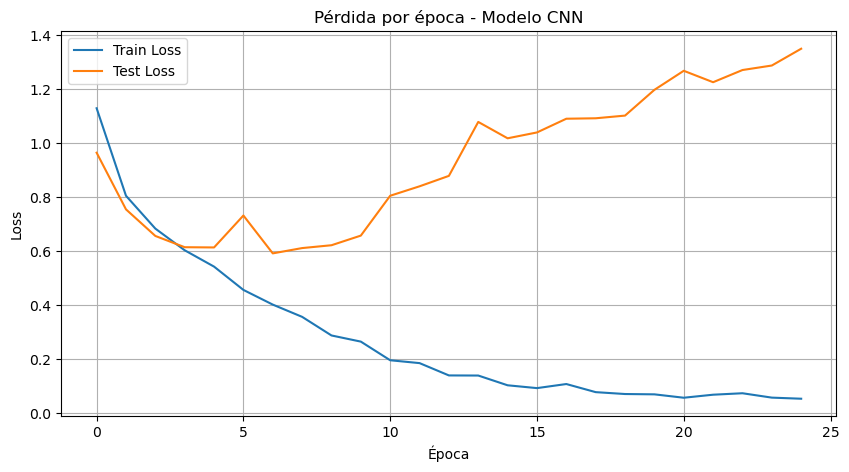

In [18]:
# Graficamos la evolución de la función de pérdida (Loss) del conjunto
# de entrenamiento y del conjunto de test utilizado como validación.
# La comparación de ambas curvas permite evaluar el aprendizaje del
# modelo y detectar posibles signos de sobreajuste.
plt.figure(figsize=(10, 5))

plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Test Loss')

plt.title('Pérdida por época - Modelo CNN')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

La evolución de la función de pérdida muestra que el Train Loss disminuyó de forma continua a lo largo del entrenamiento, indicando que la red neuronal convolucional aprendió eficazmente los patrones presentes en el conjunto de entrenamiento. Sin embargo, el Test Loss solo disminuyó durante las primeras épocas y posteriormente comenzó a incrementarse de manera sostenida, mientras que la pérdida de entrenamiento continuó reduciéndose. Este comportamiento evidencia la presencia de sobreajuste (overfitting), ya que el modelo mejora su desempeño sobre los datos de entrenamiento, pero pierde capacidad de generalización sobre datos no vistos. Estos resultados justifican la implementación de una CNN mejorada con técnicas de regularización, como Batch Normalization, Dropout y Early Stopping, para reducir el sobreajuste y mejorar el rendimiento del modelo.

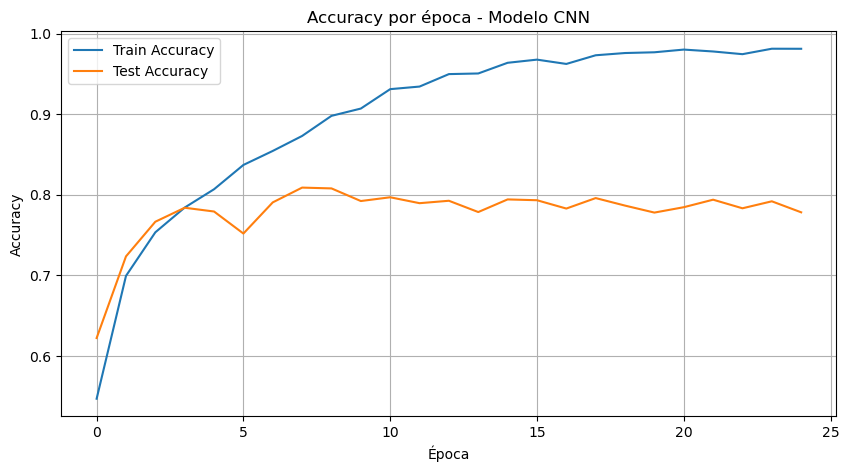

In [19]:
# Graficamos la evolución del Accuracy del conjunto de entrenamiento
# y del conjunto de test utilizado como validación. La comparación
# de ambas curvas permite evaluar el desempeño del modelo y su
# capacidad de generalizar sobre datos no utilizados para el ajuste.
plt.figure(figsize=(10, 5))

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Test Accuracy')

plt.title('Accuracy por época - Modelo CNN')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

La evolución del Accuracy muestra que la red neuronal convolucional incrementó de forma constante su rendimiento sobre el conjunto de entrenamiento, alcanzando valores cercanos al 98%. En contraste, el Accuracy del conjunto de prueba aumentó durante las primeras épocas hasta situarse alrededor del 80%, para luego estabilizarse e incluso presentar ligeras disminuciones. La creciente diferencia entre ambas curvas confirma la presencia de sobreajuste (overfitting), ya que el modelo continúa mejorando su desempeño sobre los datos de entrenamiento sin obtener mejoras equivalentes en datos no utilizados durante el aprendizaje. Estos resultados refuerzan la necesidad de incorporar técnicas de regularización en la siguiente arquitectura para mejorar la capacidad de generalización del modelo.

Se desarrolló una red neuronal convolucional compuesta por **cuatro capas convolucionales** y **dos capas densas**, con un total de **7.996.856 parámetros entrenables**, cumpliendo el requisito de mantener la cantidad de parámetros dentro del intervalo de **3 a 8 millones** establecido en el desafío. El modelo fue entrenado durante **25 épocas** y alcanzó un **Accuracy de 77,83%** sobre el conjunto de prueba.

En comparación con la red **Fully Connected** implementada anteriormente, la CNN obtuvo una mejora de aproximadamente **17 puntos porcentuales** en el Accuracy, evidenciando una mayor capacidad para extraer patrones espaciales presentes en las imágenes. Asimismo, el **Classification Report** mostró un desempeño más equilibrado entre las distintas categorías, especialmente en las clases **forest** y **street**.

El análisis de las curvas de entrenamiento evidenció la aparición de **sobreajuste** a partir de las últimas épocas, ya que la pérdida de validación comenzó a incrementarse mientras el Accuracy del conjunto de entrenamiento continuó mejorando. A pesar de ello, la arquitectura convolucional logró un rendimiento significativamente superior al modelo **Fully Connected**, confirmando su mayor capacidad para abordar tareas de clasificación de imágenes.


### 4. Implementa una red neuronal Convolucional que mejore la capacidad de generalización alcanzada en el modelo anterior. Para esto usa 16 o más capas (entre convolucionales y densas) y mide su rendimiento. 
### Luego, con el modelo entrenado, aplícalo sobre el conjunto de predicción, mide su rendimiento y compáralo con el rendimiento calculado en el modelo anterior. ¿Para qué etiqueta el modelo se equivoca más? Muestra en forma aleatoria ocho imágenes con la etiqueta de predicción otorgada por el modelo.


In [20]:
# Construimos una segunda red neuronal convolucional mejorada.
# Esta arquitectura utiliza 16 o más capas entre convolucionales,
# normalización, pooling, dropout y capas densas, cumpliendo con
# el requisito solicitado en el desafío.
cnn_model_v2 = Sequential()

# Bloque 1:
# Extrae características visuales iniciales de bajo nivel, como bordes,
# colores y texturas simples. BatchNormalization ayuda a estabilizar
# el entrenamiento y Dropout reduce el riesgo de sobreajuste.
cnn_model_v2.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
cnn_model_v2.add(BatchNormalization())
cnn_model_v2.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
cnn_model_v2.add(BatchNormalization())
cnn_model_v2.add(MaxPooling2D((2, 2)))
cnn_model_v2.add(Dropout(0.25))

# Bloque 2:
# Aumenta la cantidad de filtros para capturar patrones visuales
# más complejos en las imágenes.
cnn_model_v2.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
cnn_model_v2.add(BatchNormalization())
cnn_model_v2.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
cnn_model_v2.add(BatchNormalization())
cnn_model_v2.add(MaxPooling2D((2, 2)))
cnn_model_v2.add(Dropout(0.30))

# Bloque 3:
# Profundiza la extracción de características, capturando formas
# y estructuras más representativas de cada clase.
cnn_model_v2.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
cnn_model_v2.add(BatchNormalization())
cnn_model_v2.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
cnn_model_v2.add(BatchNormalization())
cnn_model_v2.add(MaxPooling2D((2, 2)))
cnn_model_v2.add(Dropout(0.35))

# Bloque 4:
# Extrae características de alto nivel antes de pasar a la etapa
# de clasificación. GlobalAveragePooling2D reduce la cantidad de
# parámetros respecto de Flatten, ayudando a mejorar la generalización.
cnn_model_v2.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
cnn_model_v2.add(BatchNormalization())
cnn_model_v2.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
cnn_model_v2.add(BatchNormalization())
cnn_model_v2.add(GlobalAveragePooling2D())

# Capas densas:
# Utilizadas para realizar la clasificación final a partir de las
# características extraídas por los bloques convolucionales.
cnn_model_v2.add(Dense(256, activation='relu'))
cnn_model_v2.add(BatchNormalization())
cnn_model_v2.add(Dropout(0.5))

cnn_model_v2.add(Dense(128, activation='relu'))
cnn_model_v2.add(Dropout(0.4))

# Capa de salida con seis neuronas, una por cada clase.
# Softmax entrega la probabilidad asociada a cada categoría.
cnn_model_v2.add(Dense(6, activation='softmax'))

# Compilamos el modelo utilizando Adam y categorical_crossentropy,
# adecuados para un problema de clasificación multiclase.
cnn_model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Mostramos el resumen de la arquitectura para verificar la cantidad
# de capas y parámetros entrenables.
cnn_model_v2.summary()

c:\Users\deadm\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,276,582 (4.87 MB)

 Trainable params: 1,274,150 (4.86 MB)

 Non-trainable params: 2,432 (9.50 KB)

Se implementó una red neuronal convolucional mejorada compuesta por más de 16 capas entre capas convolucionales, de normalización, agrupamiento, regularización y capas densas, cumpliendo el requisito establecido en el desafío. La arquitectura incorpora técnicas como Batch Normalization, Dropout y Global Average Pooling, diseñadas para mejorar la estabilidad del entrenamiento, reducir el sobreajuste y favorecer una mejor capacidad de generalización. El modelo cuenta con 1.276.582 parámetros, una cantidad considerablemente menor que la CNN anterior, lo que permite disminuir la complejidad computacional sin sacrificar la capacidad de aprendizaje. Se espera que estas mejoras arquitectónicas permitan obtener un mejor rendimiento sobre el conjunto de prueba en comparación con el modelo convolucional desarrollado previamente.

In [21]:
# Configuramos un criterio de Early Stopping para detener el
# entrenamiento cuando la pérdida del conjunto de validación
# (en este caso, el conjunto de test utilizado como validación)
# deje de mejorar durante cinco épocas consecutivas.
# Además, se restauran automáticamente los pesos correspondientes
# a la mejor época obtenida durante el entrenamiento.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Se configuró la técnica de Early Stopping para supervisar la pérdida del conjunto de validación y detener automáticamente el entrenamiento cuando esta deja de mejorar durante cinco épocas consecutivas. Además, se habilitó la restauración de los pesos correspondientes a la mejor época alcanzada, evitando conservar un modelo sobreajustado. Esta estrategia contribuye a mejorar la capacidad de generalización del modelo, reducir el tiempo de entrenamiento y obtener un rendimiento más estable sobre datos no utilizados durante el aprendizaje.

In [22]:
# Entrenamos la red neuronal convolucional mejorada utilizando el
# conjunto de entrenamiento durante un máximo de 25 épocas. En cada
# época se evalúa el modelo sobre el conjunto de test utilizado como
# datos de validación. Además, se aplica Early Stopping para detener
# automáticamente el entrenamiento cuando la pérdida de validación
# deja de mejorar, conservando los pesos del mejor modelo obtenido.
history_cnn_v2 = cnn_model_v2.fit(
    cnn_train_X,
    cnn_train_y_encoded,
    epochs=25,
    batch_size=64,
    validation_data=(cnn_test_X, cnn_test_y_encoded),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 60s 236ms/step - accuracy: 0.5460 - loss: 1.2861 - val_accuracy: 0.1700 - val_loss: 5.3752
Epoch 2/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 64s 291ms/step - accuracy: 0.6967 - loss: 0.8637 - val_accuracy: 0.4247 - val_loss: 2.2344
Epoch 3/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 66s 299ms/step - accuracy: 0.7409 - loss: 0.7369 - val_accuracy: 0.6373 - val_loss: 1.2122
Epoch 4/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 58s 262ms/step - accuracy: 0.7778 - loss: 0.6417 - val_accuracy: 0.7210 - val_loss: 0.7424
Epoch 5/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 75s 228ms/step - accuracy: 0.7856 - loss: 0.6218 - val_accuracy: 0.7620 - val_loss: 0.6679
Epoch 6/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 55s 251ms/step - accuracy: 0.7998 - loss: 0.5717 - val_accuracy: 0.8127 - val_loss: 0.5609
Epoch 7/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 52s 237ms/step - accuracy: 0.8167 - loss: 0.5389 - val_accuracy: 0.8020 - val_loss: 0.5750
Epoch 8/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 51s 233ms/step - accuracy: 0.8278 - loss: 0

La CNN mejorada fue entrenada utilizando Early Stopping, lo que permitió detener automáticamente el proceso cuando la pérdida del conjunto de validación dejó de mejorar. Aunque se definieron un máximo de 25 épocas, el entrenamiento finalizó anticipadamente al detectarse el inicio del sobreajuste. Durante las épocas ejecutadas, el Accuracy del conjunto de entrenamiento aumentó progresivamente, mientras que el Accuracy del conjunto de validación alcanzó valores cercanos al 83%, mostrando un comportamiento más estable que el observado en la CNN anterior. Estos resultados indican que las técnicas de Batch Normalization, Dropout y Early Stopping contribuyeron a mejorar la capacidad de generalización del modelo y a reducir el efecto del sobreajuste.

In [23]:
# Evaluamos el rendimiento de la CNN mejorada utilizando el conjunto
# de prueba. Se calculan la función de pérdida (Loss) y el Accuracy
# sobre datos no utilizados durante el entrenamiento, permitiendo
# medir la capacidad de generalización del modelo mejorado.
loss_cnn_v2, accuracy_cnn_v2 = cnn_model_v2.evaluate(
    cnn_test_X,
    cnn_test_y_encoded,
    verbose=1
)
# Mostramos las métricas obtenidas sobre el conjunto de prueba.
print("Loss Test CNN Mejorada:", round(loss_cnn_v2, 4))
print("Accuracy Test CNN Mejorada:", round(accuracy_cnn_v2, 4))

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8270 - loss: 0.5059
Loss Test CNN Mejorada: 0.5059
Accuracy Test CNN Mejorada: 0.827


La evaluación de la CNN mejorada sobre el conjunto de prueba arrojó un Accuracy de 82,70% y una Loss de 0,5059, superando el desempeño obtenido por la CNN anterior (77,83% de Accuracy). Esta mejora confirma que la incorporación de técnicas como Batch Normalization, Dropout y Early Stopping permitió incrementar la capacidad de generalización del modelo y reducir el efecto del sobreajuste observado en la arquitectura previa. En consecuencia, la CNN mejorada constituye el modelo con mejor rendimiento entre todas las arquitecturas evaluadas en este desafío.

In [24]:
# Generamos las probabilidades de pertenencia a cada una de las
# seis clases utilizando el conjunto de prueba.
y_proba_cnn_v2 = cnn_model_v2.predict(cnn_test_X)

# Convertimos las probabilidades en la clase predicha, seleccionando
# aquella con la mayor probabilidad para cada imagen.
y_pred_cnn_v2 = np.argmax(y_proba_cnn_v2, axis=1)

# Transformamos las etiquetas reales codificadas con One-Hot a su
# representación original para compararlas con las predicciones.
y_true_cnn = np.argmax(cnn_test_y_encoded, axis=1)

# Mostramos el reporte de clasificación, el cual incluye las métricas
# Precision, Recall, F1-Score y Support para cada una de las categorías.
print("Classification Report - CNN Mejorada")
print(classification_report(
    y_true_cnn,
    y_pred_cnn_v2,
    target_names=class_names
))
# Calculamos la matriz de confusión para analizar la cantidad de
# clasificaciones correctas e incorrectas realizadas por el modelo
# en cada una de las categorías.
cm_cnn_v2 = confusion_matrix(
    y_true_cnn,
    y_pred_cnn_v2
)
# Mostramos la matriz de confusión obtenida.
print("Matriz de confusión:")
print(cm_cnn_v2)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step
Classification Report - CNN Mejorada
              precision    recall  f1-score   support

   buildings       0.86      0.76      0.81       437
      forest       0.91      0.96      0.94       474
     glacier       0.72      0.86      0.78       553
    mountain       0.86      0.72      0.78       525
         sea       0.78      0.84      0.80       510
      street       0.87      0.83      0.85       501

    accuracy                           0.83      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000

Matriz de confusión:
[[331  20  11   7  23  45]
 [  3 457   2   1   3   8]
 [  5   2 473  41  31   1]
 [  4   3  88 377  53   0]
 [  6   2  64   6 426   6]
 [ 34  17  16   4  13 417]]


El Classification Report y la matriz de confusión muestran que la CNN mejorada obtuvo un rendimiento más equilibrado entre todas las categorías, alcanzando un Accuracy cercano al 83% sobre el conjunto de prueba. La clase forest presentó el mejor desempeño (F1-Score = 0,94), mientras que glacier y mountain continuaron siendo las categorías con mayor dificultad de clasificación debido a sus similitudes visuales. No obstante, en comparación con la CNN anterior, se observa una reducción en los errores de clasificación y una mejora general en las métricas de Precision, Recall y F1-Score, confirmando que las técnicas de regularización incorporadas permitieron incrementar la capacidad de generalización del modelo.

In [25]:
# Calculamos la cantidad de errores cometidos por el modelo para
# cada una de las categorías. Para ello, restamos de la cantidad
# total de observaciones por clase los aciertos registrados en la
# diagonal principal de la matriz de confusión.
errores_por_clase = cm_cnn_v2.sum(axis=1) - np.diag(cm_cnn_v2)

# Construimos una tabla con el número de errores por categoría y la
# ordenamos de mayor a menor para identificar las clases donde el
# modelo presenta un peor desempeño.
errores_df = pd.DataFrame({
    'Clase': class_names,
    'Errores': errores_por_clase
}).sort_values(
    by='Errores',
    ascending=False
)
# Mostramos la tabla con la cantidad de errores por clase.
display(errores_df)

,Clase,Errores
3,mountain,148
0,buildings,106
5,street,84
4,sea,84
2,glacier,80
1,forest,17


El análisis de los errores por categoría permite identificar las clases en las que el modelo presenta mayores dificultades de clasificación. La categoría mountain registró la mayor cantidad de errores (148), seguida por buildings (106), lo que indica que estas clases continúan siendo las más complejas de distinguir. En contraste, la categoría forest obtuvo únicamente 17 errores, evidenciando que es la clase mejor aprendida por el modelo. En general, la distribución de errores confirma que la CNN mejorada presenta un comportamiento más consistente entre las distintas categorías, aunque persisten algunas confusiones entre clases con características visuales similares.

In [26]:
# Construimos una tabla comparativa con las métricas obtenidas por
# la CNN original y la CNN mejorada. La comparación del Accuracy y
# la función de pérdida (Loss) permite evaluar si la nueva arquitectura
# logró mejorar el rendimiento y la capacidad de generalización del modelo.
comparacion_modelos = pd.DataFrame({
    'Modelo': [
        'CNN anterior',
        'CNN mejorada'
    ],
    'Accuracy Test': [
        accuracy_cnn,
        accuracy_cnn_v2
    ],
    'Loss Test': [
        loss_cnn,
        loss_cnn_v2
    ]
})
# Mostramos la tabla comparativa de resultados obtenidos por ambos modelos.
display(comparacion_modelos)

,Modelo,Accuracy Test,Loss Test
0,CNN anterior,0.778333,1.349482
1,CNN mejorada,0.827000,0.505869


La comparación entre ambos modelos demuestra que la CNN mejorada superó el rendimiento de la CNN original, aumentando el Accuracy desde 77,83% hasta 82,70% y reduciendo la Loss desde 1,3495 hasta 0,5059. Estos resultados evidencian una mejor capacidad de generalización y una mayor estabilidad durante el proceso de clasificación. La incorporación de técnicas como Batch Normalization, Dropout y Early Stopping permitió reducir el sobreajuste observado en la arquitectura anterior, obteniendo un modelo más preciso y robusto para la clasificación de imágenes.

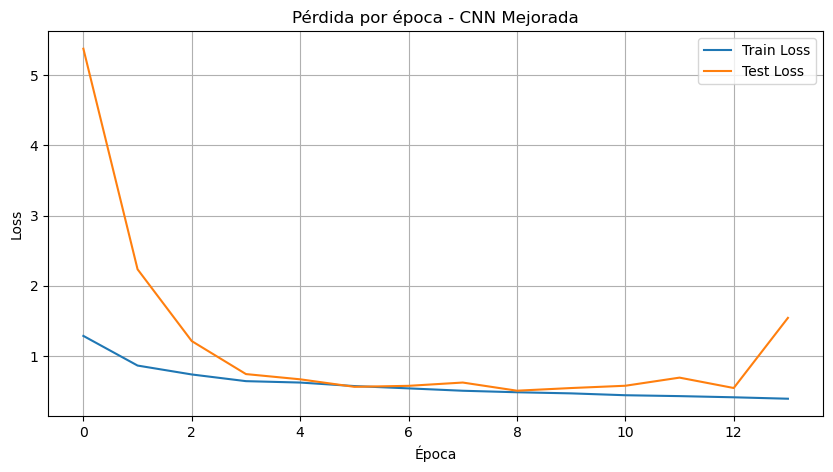

In [27]:
# Graficamos la evolución de la función de pérdida (Loss) durante el
# entrenamiento y su evaluación sobre el conjunto de test utilizado
# como datos de validación. La comparación de ambas curvas permite
# analizar el aprendizaje del modelo, evaluar su capacidad de
# generalización e identificar posibles signos de sobreajuste.
plt.figure(figsize=(10, 5))

plt.plot(history_cnn_v2.history['loss'], label='Train Loss')
plt.plot(history_cnn_v2.history['val_loss'], label='Test Loss')

plt.title('Pérdida por época - CNN Mejorada')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

La evolución de la función de pérdida muestra que la CNN mejorada logró reducir rápidamente tanto la pérdida de entrenamiento como la de validación durante las primeras épocas. A diferencia de la CNN anterior, ambas curvas permanecieron próximas durante gran parte del entrenamiento, lo que indica una mejor capacidad de generalización y un menor grado de sobreajuste. En las últimas épocas se observa un incremento en la pérdida de validación, motivo por el cual el criterio de Early Stopping restauró automáticamente los pesos correspondientes a la mejor época alcanzada. En conjunto, estos resultados evidencian que las técnicas de regularización incorporadas permitieron obtener un entrenamiento más estable y un modelo con mejor desempeño sobre datos no utilizados durante el aprendizaje.

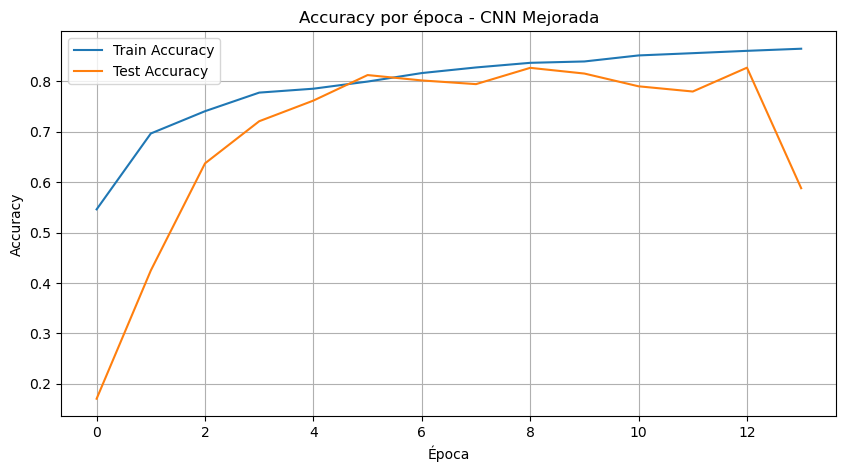

In [28]:
# Graficamos la evolución del Accuracy durante el entrenamiento y
# su evaluación sobre el conjunto de test utilizado como datos de
# validación. La comparación de ambas curvas permite analizar la
# capacidad de aprendizaje del modelo, evaluar su generalización y
# verificar si las mejoras incorporadas reducen el sobreajuste.
plt.figure(figsize=(10, 5))

plt.plot(history_cnn_v2.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_v2.history['val_accuracy'], label='Test Accuracy')

plt.title('Accuracy por época - CNN Mejorada')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

La evolución del Accuracy muestra que el modelo incrementó progresivamente su rendimiento sobre el conjunto de entrenamiento a medida que avanzaron las épocas. En el conjunto de validación, el Accuracy aumentó rápidamente durante las primeras épocas y luego se mantuvo relativamente estable, alcanzando su mejor desempeño antes de que se activara el criterio de Early Stopping. Aunque en la última época se observa una disminución del Accuracy de validación, el modelo conserva los pesos correspondientes a la mejor época, evitando que este descenso afecte el rendimiento final. En comparación con la CNN anterior, el entrenamiento fue más estable y la capacidad de generalización mejoró, lo que se refleja en el Accuracy final de 82,7% obtenido sobre el conjunto de prueba.

In [29]:
# Aplicamos la CNN mejorada al conjunto de predicción para obtener
# la probabilidad de pertenencia de cada imagen a las seis categorías.
y_proba_pred = cnn_model_v2.predict(cnn_pred_X)

# Convertimos las probabilidades en la clase predicha, seleccionando
# la categoría con la mayor probabilidad para cada imagen.
y_pred_pred = np.argmax(y_proba_pred, axis=1)

# Traducimos los índices predichos a los nombres de las categorías
# originales para facilitar la interpretación de los resultados.
pred_labels = class_names[y_pred_pred]

# Mostramos las primeras veinte etiquetas predichas por el modelo.
print(pred_labels[:20])

229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step
['sea' 'mountain' 'glacier' 'forest' 'forest' 'forest' 'glacier' 'forest'
 'sea' 'sea' 'buildings' 'buildings' 'buildings' 'buildings' 'glacier'
 'buildings' 'mountain' 'glacier' 'mountain' 'glacier']


La CNN mejorada fue aplicada al conjunto de predicción para asignar una categoría a cada una de las imágenes no etiquetadas. Para ello, el modelo calculó la probabilidad de pertenencia a cada una de las seis clases y seleccionó aquella con la mayor probabilidad como predicción final. Las primeras veinte etiquetas obtenidas muestran que el modelo es capaz de generar clasificaciones sobre nuevas imágenes, las cuales serán analizadas posteriormente mediante la distribución de predicciones y la visualización de ejemplos aleatorios.

In [30]:
# Calculamos la cantidad de imágenes clasificadas en cada categoría
# dentro del conjunto de predicción. Esto permite conocer la
# distribución de las clases asignadas por la CNN mejorada y analizar
# cómo se reparten las predicciones realizadas por el modelo.
pred_counts = pd.Series(pred_labels).value_counts().sort_index()

# Mostramos la frecuencia de imágenes predichas para cada categoría.
display(pred_counts)

buildings     997
forest       1272
glacier      1477
mountain     1114
sea          1250
street       1191
Name: count, dtype: int64

La distribución de las predicciones muestra que la CNN mejorada asignó imágenes a las seis categorías disponibles, evidenciando que el modelo utiliza todas las clases durante el proceso de clasificación. La categoría glacier fue la más predicha, con 1.477 imágenes, mientras que buildings fue la menos frecuente, con 997 imágenes. Dado que el conjunto de predicción no dispone de etiquetas reales, estos resultados no permiten evaluar la precisión del modelo, pero sí ofrecen una visión de cómo se distribuyen las clases asignadas sobre datos no etiquetados.

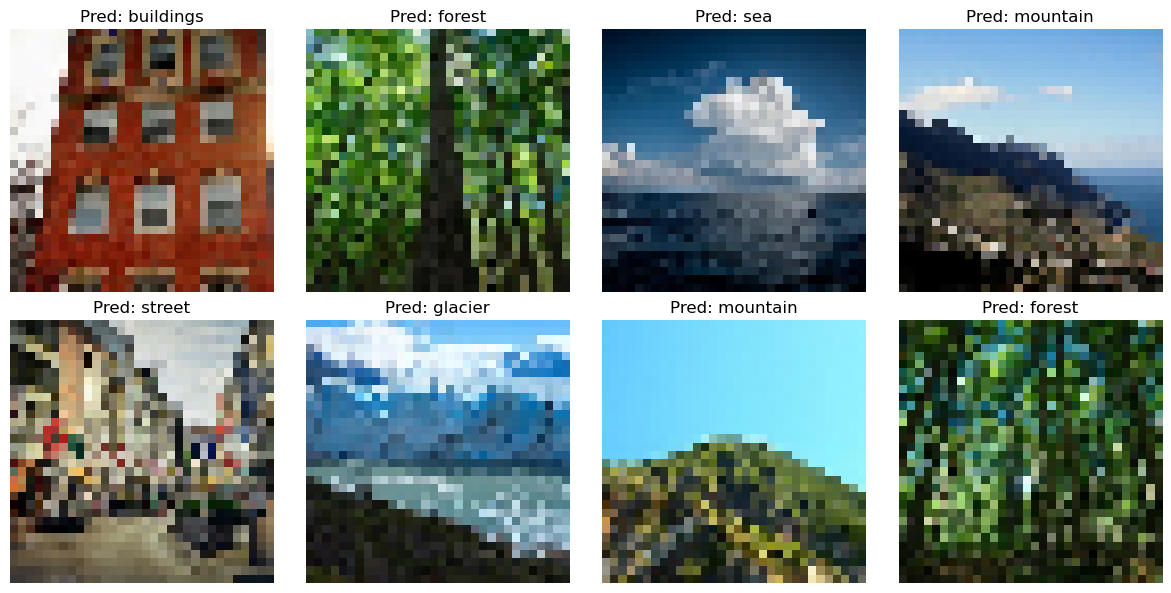

In [31]:
# Seleccionamos de forma aleatoria ocho imágenes del conjunto de
# predicción para visualizar el desempeño del modelo sobre datos
# no etiquetados. Se fija una semilla para garantizar la
# reproducibilidad de la selección.
np.random.seed(42)

indices_pred = np.random.choice(
    len(cnn_pred_X),
    size=8,
    replace=False
)
# Mostramos las ocho imágenes seleccionadas junto con la etiqueta
# predicha por la CNN mejorada, permitiendo realizar una evaluación
# visual de las clasificaciones obtenidas por el modelo.
plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices_pred):
    plt.subplot(2, 4, i + 1)
    plt.imshow(cnn_pred_X[idx])
    plt.title(f'Pred: {pred_labels[idx]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Las ocho imágenes seleccionadas aleatoriamente muestran predicciones visualmente coherentes con su contenido. En ellas se observan escenas que el modelo clasificó como buildings, forest, mountain, sea, street y glacier, cuyas etiquetas resultan plausibles de acuerdo con las características visibles de cada imagen. Si bien no es posible confirmar la exactitud de estas predicciones debido a que el conjunto de predicción no dispone de etiquetas reales, la inspección visual sugiere que el modelo logró aprender características relevantes para diferenciar las distintas categorías de paisajes y generalizar su desempeño sobre imágenes no vistas durante el entrenamiento.

### Conclusión
Se implementó una red neuronal convolucional mejorada utilizando más de 16 capas entre capas convolucionales, de normalización, agrupamiento, regularización y capas densas. El modelo incorporó técnicas como Batch Normalization, Dropout y Global Average Pooling, con el objetivo de mejorar su capacidad de generalización respecto al modelo CNN desarrollado previamente.

El modelo alcanzó un Accuracy de 82,70% sobre el conjunto de prueba, superando el rendimiento del modelo anterior, que obtuvo 77,83%. Asimismo, la función de pérdida disminuyó desde 1,3495 hasta 0,5059, evidenciando una mejora significativa en el desempeño del clasificador.

El análisis de la matriz de confusión mostró que la categoría mountain presentó la mayor cantidad de errores de clasificación (148 errores), mientras que forest fue la categoría con mejor desempeño, registrando únicamente 17 errores.

Finalmente, el modelo fue aplicado sobre un conjunto de imágenes sin etiquetas, obteniendo predicciones visualmente coherentes con el contenido de las escenas observadas. Si bien no es posible verificar su exactitud al no disponer de etiquetas reales, los resultados sugieren que la arquitectura propuesta logró una mejor capacidad de generalización y una mayor robustez para la clasificación de nuevas imágenes.
